In [5]:
from netCDF4 import Dataset
from datetime import *
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from glob import glob
# from mpl_toolkits.basemap import Basemap
import seawater as sw
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Plots statiscal analysis for specific Area of Eddy formation 



In [10]:
def smoo(self,nw):
    import scipy.signal as sg
    win = np.blackman(nw)
    win=win[None,:]*win[:,None]
    peso=sg.fftconvolve(np.ones(self.shape),win,mode='same')
    dataout=sg.fftconvolve(self,win,mode='same')/peso

    return dataout




def geocut(xb,yb,var,ltmn,lnmn,ltmx,lnmx):
    if len(xb.shape)>1:
        indx=np.argwhere((xb[0,:]>=lnmn)&(xb[0,:]<=lnmx)).T[0]
        indy=np.argwhere((yb[:,0]>=ltmn)&(yb[:,0]<=ltmx)).T[0]
        xnew=xb[indy,:][:,indx]
        ynew=yb[indy,:][:,indx]

    else:
        indx=np.argwhere((xb>=lnmn)&(xb<=lnmx)).T[0]
        indy=np.argwhere((yb>=ltmn)&(yb<=ltmx)).T[0]
        xnew=xb[indx]
        ynew=yb[indy]

    varnew=var[indy,:][:,indx]
    return xnew,ynew,varnew

def fig1(sizeh,sizev,lnmn,lnmx,ltmn,ltmx):
    ltmn=-29;ltmx=-14;lnmn=-52;lnmx=-35.
    plt.rcParams['font.size']=18
    plt.rcParams['font.sans-serif']='Arial'
    plt.rcParams['font.family'] = "sans-serif"
    plt.rcParams['font.weight']='bold'


    fig = plt.figure(figsize=(sizeh,sizev))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([lnmn, lnmx, ltmn, ltmx], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.LAKES)


    # ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES)


    ax = plt.axes(projection=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
#     plt.show()
    

### Loading data

In [18]:
# var=Dataset('/home/igor/Documents/AntSimi/altdata/clim/sla_climatology.nc')
# lonc,latc=var['longitude'][:]-360,var['latitude'][:];
# slac=var['sla'][:]

dt0=datetime(1950,1,1)
# dt=[dt0 + timedelta(days=np.int(dia)) for dia in var['time']]

'Loading Tracks'
anc=Dataset('/Users/iufarias/Documents/META3.1exp/META3.1exp_DT_allsat_Anticyclonic_long_19930101_20200307.nc')
cnc=Dataset('/Users/iufarias/Documents/META3.1exp/META3.1exp_DT_allsat_Cyclonic_long_19930101_20200307.nc')




### Areas of Formation

In [19]:
edatabase=[[-16,-14,-39.5,-37.5,anc,1,'lightsalmon','IE'],
            [-18,-16,-39,-37,anc,1,'chocolate','RCE'],
            [-20,-18,-38,-36,anc,1,'crimson','AE'],
            [-21.25,-19.25,-39.750,-37.750,cnc,-1,'navy','VE'],
            [-22,-20,-40.5,-38.5,anc,1,'darkorange','SVE'],
            [-24,-22,-41,-39,cnc,-1,'cornflowerblue','CSTE'],
            [-25,-23,-43,-41,cnc,-1,'mediumseagreen','CFE'],]

### Delimited Area

In [20]:

# dd=pd.read_csv('/home/igor/Documents/AntSimi/data/buffer_200m_6rad.csv')
dd=pd.read_csv('/Users/iufarias/Documents/META3.1exp/bat/buffer_200m_200km.csv')
ddlon,ddlat=np.array(dd['lon']),np.array(dd['lat'])
ddseg=Path(np.array([ddlon,ddlat]).T)


### Bathymetry

In [21]:

ltmn=-29;ltmx=-14;lnmn=-52;lnmx=-35.

topo=Dataset('/Users/iufarias/Documents/META3.1exp/bat/etopo1_bedrock.nc')
xb=topo['lon'][:];yb=topo['lat'][:];zb=topo['Band1'][:];
zb=smoo(zb,20)
xxb,yyb=np.meshgrid(xb,yb);

### Bathymetric Path

In [22]:

c=plt.contourf(xb,yb,zb,levels=[-200,np.inf],colors='k')
plt.close()
segs=[]

for iss in range(len(c.allsegs)):
    # col=c.collections[iss].get_paths()
    col=c.allsegs[iss]

    lens=list(map(len,col))
    indl=np.argmax(lens)
    segs.append(col[indl])

segs=np.vstack(segs);
pseg=Path(segs)


In [23]:
Table=pd.DataFrame([])


### Map of Regions of Formation



<ipython-input-10-20b1a6ddfd4d>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


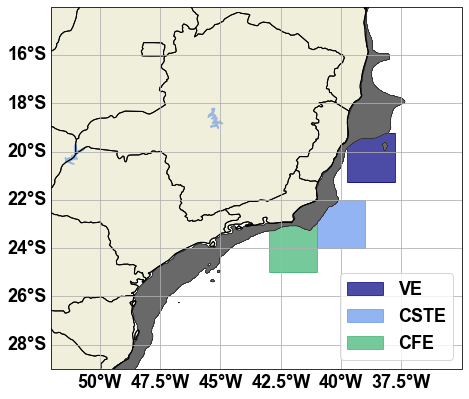

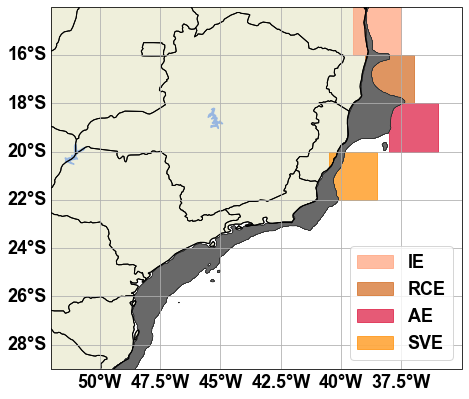

In [24]:

'CYCLONES'

ltmns=-28;ltmxs=-13;lnmns=-46;lnmxs=-35.

fig1(sizeh=6.24,sizev=9.22,lnmn=lnmns,lnmx=lnmxs,ltmn=ltmns,ltmx=ltmxs)

for ity in range(len(edatabase)):
    ltmnw,ltmxw,lnmnw,lnmxw,_,pol,colorw,strw=edatabase[ity]
    if pol==-1:
        plt.fill_between([lnmnw,lnmxw],ltmnw,ltmxw,color=colorw,label=strw,alpha=0.7) 

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Region_MAP_cyc.png')
# plt.close()


'ANTICYCLONES'
fig1(sizeh=6.24,sizev=9.22,lnmn=lnmns,lnmx=lnmxs,ltmn=ltmns,ltmx=ltmxs)

for ity in range(len(edatabase)):
    ltmnw,ltmxw,lnmnw,lnmxw,_,pol,colorw,strw=edatabase[ity]
    if pol==1:
        plt.fill_between([lnmnw,lnmxw],ltmnw,ltmxw,color=colorw,label=strw,alpha=0.7) 

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Region_MAP_anti.png')
# plt.close()


<ipython-input-25-557842f74ef8>:72: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xtime= [datetime(1950,1,1)+ timedelta(days=np.int(tem)) for tem in Xtime]
<ipython-input-25-557842f74ef8>:110: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional in

IE 84.0
IE 0    16.0
1    17.0
2    22.0
3    29.0
dtype: float64 ['Summer', 'Autumn', 'Winter', 'Spring']


<ipython-input-25-557842f74ef8>:460: RuntimeWarning: invalid value encountered in multiply
  efold=np.empty([edays,len(raix)])*np.nan;
<ipython-input-25-557842f74ef8>:461: RuntimeWarning: invalid value encountered in multiply
  tfold=np.empty([edays,len(raix)])*np.nan;
<ipython-input-25-557842f74ef8>:462: RuntimeWarning: invalid value encountered in multiply
  xfold=np.empty([edays,50,len(raix)])*np.nan;
<ipython-input-25-557842f74ef8>:463: RuntimeWarning: invalid value encountered in multiply
  yfold=np.empty([edays,50,len(raix)])*np.nan;
<ipython-input-25-557842f74ef8>:492: RuntimeWarning: Mean of empty slice
  plt.plot(np.arange(edays),np.nanmean(efold,axis=1),'k')
<ipython-input-25-557842f74ef8>:493: RuntimeWarning: Mean of empty slice
  plt.fill_between(np.arange(edays),y1=np.nanmean(efold,axis=1) - np.nanstd(efold,axis=1),
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, 

IE had no 100 days dev.


<ipython-input-25-557842f74ef8>:72: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xtime= [datetime(1950,1,1)+ timedelta(days=np.int(tem)) for tem in Xtime]
<ipython-input-25-557842f74ef8>:110: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional in

RCE 87.0
RCE 0    22.0
1    21.0
2    23.0
3    21.0
dtype: float64 ['Summer', 'Autumn', 'Winter', 'Spring']


KeyboardInterrupt: 

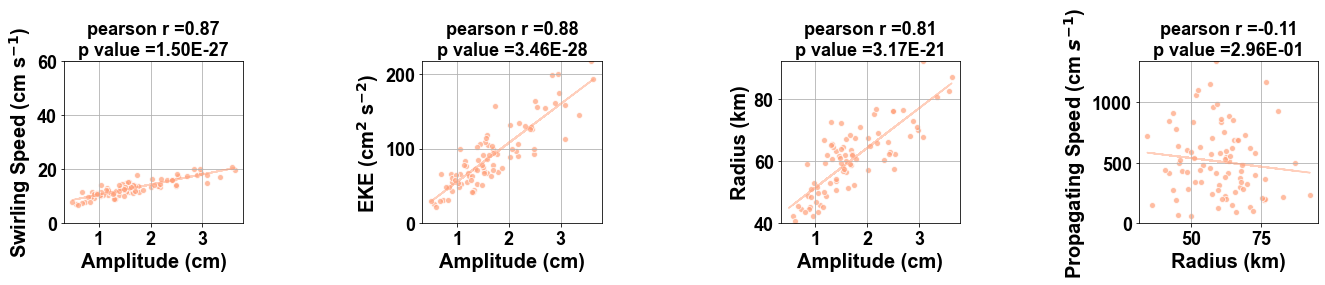

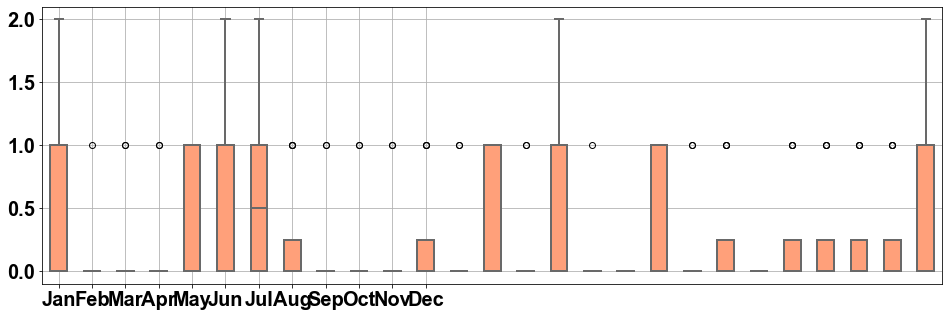

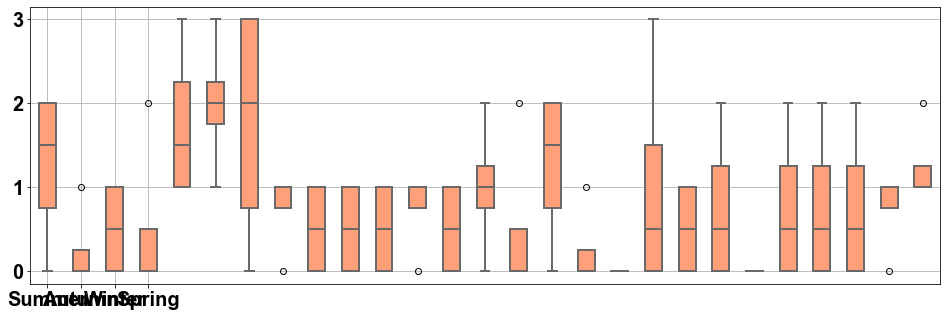

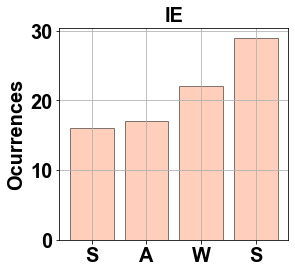

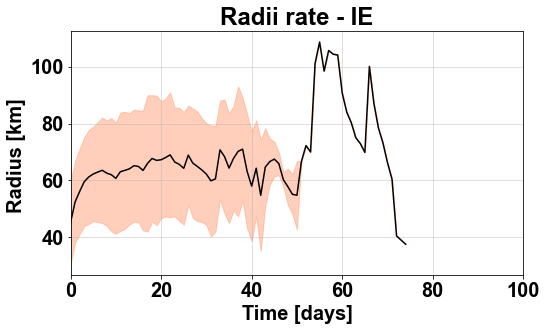

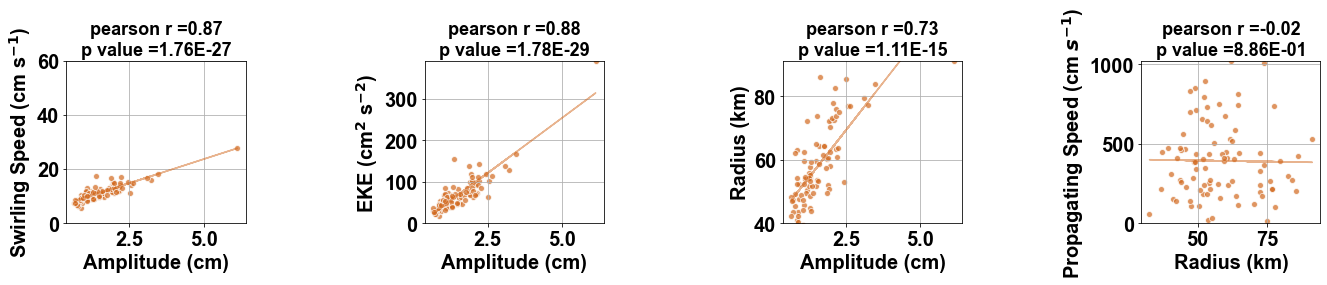

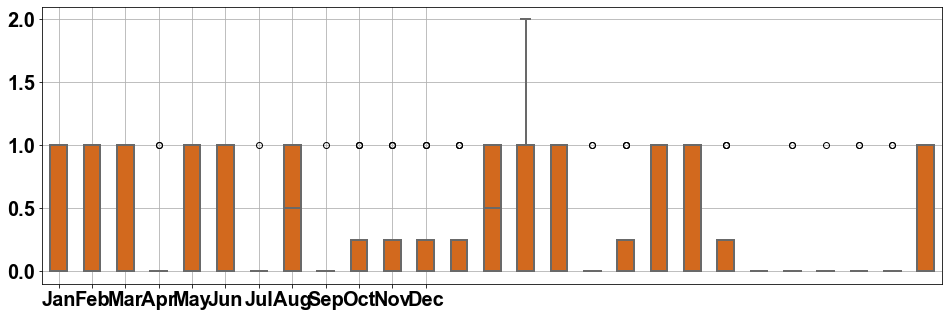

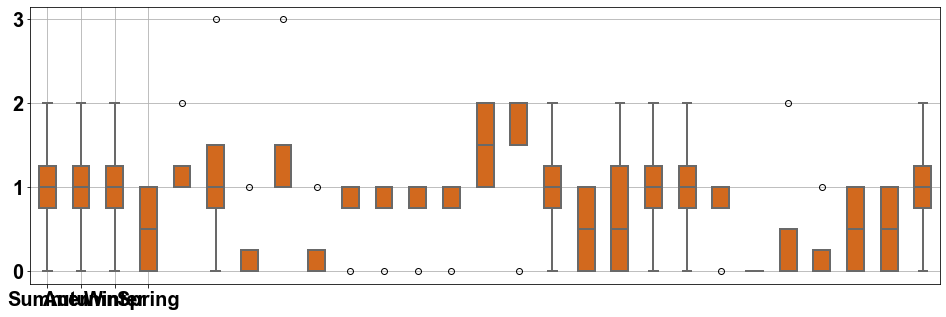

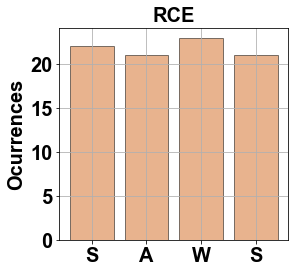

In [25]:
iltmn=-29;iltmx=-14;ilnmn=-52;ilnmx=-35.

dbol=False
ny=27

for itt in range(len(edatabase)):

    edatabase=[[-16,-14,-39.5,-37.5,anc,1,'lightsalmon','IE'],
                [-18,-16,-39,-37,anc,1,'chocolate','RCE'],
                [-20,-18,-38,-36,anc,1,'crimson','AE'],
                [-21.25,-19.25,-39.750,-37.750,cnc,-1,'navy','VE'],
                [-22,-20,-40.5,-38.5,anc,1,'darkorange','SVE'],
                [-24,-22,-41,-39,cnc,-1,'cornflowerblue','CSTE'],
                [-25,-23,-43,-41,cnc,-1,'mediumseagreen','CFE'],]

    ltmn,ltmx,lnmn,lnmx,nnc,polx,colorx,streddy=edatabase[itt]

    xtrack=nnc['track'][:]
    xobs=nnc['observation_number'][:]
    xlon,xlat=nnc['longitude'][:],nnc['latitude'][:]
    xlon=np.where(xlon>180,xlon-360,xlon)

    xtrack=np.int_(xtrack.data)

    'Condition 1 - Excluding NH++'
    condx=(xlon>ilnmn-10)&(xlon<ilnmx+10)&(xlat>iltmn-10)&(xlat<iltmx+10) #esse é o certo

    xtrack0=xtrack[condx]


    'Condition 1b - Filtering Area'
    xxx=(xobs[condx]==0)
    xx1=(xlon[condx][xxx]>lnmn)&(xlon[condx][xxx]<lnmx)&(xlat[condx][xxx]>ltmn)&(xlat[condx][xxx]<ltmx)
    ixs=xtrack0[xxx][xx1] #indices iniciais que precisam ser retirados com  o resto de suas tracks
    condx1=np.hstack([np.where(xtrack0==iy)[0] for iy in ixs])

    xtrack1=xtrack0[condx1]


    'Condition 2 - Bathtymetry'
    xxx=(xobs[condx][condx1]==0)
    xbol=[pseg.contains_point((xlon[condx][condx1][iy],xlat[condx][condx1][iy])) for iy in np.where(xxx)[0] ]
    icx=xtrack1[xxx][~np.array(xbol)]
    condx2=np.hstack([np.where(xtrack1==iy)[0] for iy in icx])

    xtrack2=xtrack1[condx2]



    'Condition 3 - Buffer zone'
    xxx=(xobs[condx][condx1][condx2]==0)
    xbol=[ddseg.contains_point((xlon[condx][condx1][condx2][iy],xlat[condx][condx1][condx2][iy])) for iy in np.where(xxx)[0] ]
    icx=xtrack2[xxx][np.array(xbol)]
    condx3=np.hstack([np.where(xtrack2==iy)[0] for iy in icx])

    xtrack3=xtrack2[condx3]





    ntrack=xtrack3.copy()
    del xtrack3,xtrack1,xtrack2


    
    uni=np.unique(ntrack)



    Xtime=nnc['time'][:][condx][condx1][condx2][condx3]
    xtime= [datetime(1950,1,1)+ timedelta(days=np.int(tem)) for tem in Xtime] 
    Xamp=pd.Series(nnc['amplitude'][:][condx][condx1][condx2][condx3]);Xamp=Xamp.groupby(ntrack).mean();
    Xvel=pd.Series(nnc['speed_average'][:][condx][condx1][condx2][condx3]);Xvel=Xvel.groupby(ntrack).mean();
    Xvelmax=pd.Series(nnc['speed_average'][:][condx][condx1][condx2][condx3]);Xvelmax=Xvelmax.groupby(ntrack).max();
    Xrad=pd.Series(nnc['effective_radius'][:][condx][condx1][condx2][condx3]);Xrad=Xrad.groupby(ntrack).mean();
    # XxContour=pd.DataFrame(nnc['effective_contour_longitude'][:])-360;
    # XyContour=pd.DataFrame(nnc['effective_contour_latitude'][:]);
    Xeke=0.5*((Xvel*100)**2)
    xlon=xlon[condx][condx1][condx2][condx3]
    xlat=xlat[condx][condx1][condx2][condx3]
    Xobs=xobs[condx][condx1][condx2][condx3]


    Xdist=[];Xdur=[];Xpvel=[];Xpvel2=[];Xpvel3=[];
    Xdate=[];Xfdate=[];


    for ui in uni:

        dur=len(ntrack[ntrack==ui])

        distx=sw.dist(lon=xlon[ntrack==ui],lat=xlat[ntrack==ui])[0]
        disty=sw.dist(lon=[xlon[ntrack==ui][0],xlon[ntrack==ui][-1]],
                lat=[xlat[ntrack==ui][0],xlat[ntrack==ui][-1]])[0]
        # distz=sw.dist(lon=[XxContour.iloc[xtrack==ui,:].mean(1).iloc[0],XxContour.iloc[xtrack==ui,:].mean(1).iloc[-1]],
        #                 lat=[XyContour.iloc[xtrack==ui,:].mean(1).iloc[0],XyContour.iloc[xtrack==ui,:].mean(1).iloc[-1]])[0]


        k=np.insert(distx,0,0)
        dist=np.cumsum(k)

        pvel=(dist[-1]*1e3)/(dur*86400)
        # pvel2=np.nanmean((distx*1e3)/(86400))
        pvel2=(disty[0]*1e3/(dur*86400))
        # pvel3=(distz[0]*1e3/(dur*86400))

        time=Xtime[ntrack==ui];

        date=dt0+ timedelta(days=np.int(time.mean()));
        fdate=dt0 + timedelta(days=np.int(time[0]));

        Xdist.append(disty[0]);
        # Xdist.append(dist[-1]);
        Xdur.append(dur);
        Xpvel.append(pvel*100);
        Xpvel2.append(pvel2*100);
        # Xpvel3.append(pvel3*100);
        Xdate.append(date);
        Xfdate.append(fdate);

    Xdist=np.array(Xdist);
    Xdur=np.array(Xdur);
    Xpvel=np.array(Xpvel);
    Xpvel2=np.array(Xpvel2);
    # Xpvel3=np.array(Xpvel3);

    vamp=0
    vrad=0
    Wc=Xrad/1e3


    # xcond=(Xamp>=vamp/100)&(Xrad>=vrad*1e3)
    xcond=(Xamp==Xamp)

    'Table'
    ttt=pd.Series({'amp':np.nanmean(Xamp[xcond]),'amp_min':np.nanmin(Xamp[xcond]),'amp_max':np.nanmax(Xamp[xcond]),'amp_std':np.nanstd(Xamp[xcond]),
                    'vel':np.nanmean(Xvel[xcond]),'vel_min':np.nanmin(Xvel[xcond]),'vel_max':np.nanmax(Xvel[xcond]),'vel_std':np.nanstd(Xvel[xcond]),
                    'rad':np.nanmean(Xrad[xcond]),'rad_min':np.nanmin(Xrad[xcond]),'rad_max':np.nanmax(Xrad[xcond]),'rad_std':np.nanstd(Xrad[xcond]),
                    'eke':np.nanmean(Xeke[xcond]),'eke_min':np.nanmin(Xeke[xcond]),'eke_max':np.nanmax(Xeke[xcond]),'eke_std':np.nanstd(Xeke[xcond]),
                    'dist':np.nanmean(Xdist[xcond]),'dist_min':np.nanmin(Xdist[xcond]),'dist_max':np.nanmax(Xdist[xcond]),'dist_std':np.nanstd(Xdist[xcond]),
                    'dur':np.nanmean(Xdur[xcond]),'dur_min':np.nanmin(Xdur[xcond]),'dur_max':np.nanmax(Xdur[xcond]),'dur_std':np.nanstd(Xdur[xcond]),
                    'pvel':np.nanmean(Xpvel[xcond]),'pvel_min':np.nanmin(Xpvel[xcond]),'pvel_max':np.nanmax(Xpvel[xcond]),'pvel_std':np.nanstd(Xpvel[xcond]),
                    'pvel2':np.nanmean(Xpvel2[xcond]),'pvel2_min':np.nanmin(Xpvel2[xcond]),'pvel2_max':np.nanmax(Xpvel2[xcond]),'pvel2_std':np.nanstd(Xpvel2[xcond])})

    ttt.name=streddy

    Table=Table.join(ttt,how='right')


    #PAREI AQUI
    'Fiuguras'
    fsz=20;

    pc=plt.figure(figsize=(18.53,  3.77))

    gs = gridspec.GridSpec(1,11)
    ax1 = plt.subplot(gs[0, 0:2])

    if polx==-1:
        Xc,Yc=-Xamp*100,Xvel*100
        # X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();
    else:
        Xc,Yc=Xamp*100,Xvel*100
        # X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();


    slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
    line = slope*(X)+intercept

    plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
    plt.plot(X,line,color=colorx,alpha=0.5)

    textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
                        'p value ={:.2E}'.format(p_value)))

    plt.title(textstr,fontweight='bold',fontsize=fsz-2)

    plt.grid()

    plt.ylabel(r'Swirling Speed (cm s$^{-1}$)',fontsize=fsz, fontweight='bold')
    plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
    plt.ylim(0,60)
    plt.xlim()



    ax2 = plt.subplot(gs[0, 3:5])

    if polx==-1:
        Xc,Yc=-Xamp*100,Xeke
        # X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();

    else:
        Xc,Yc=Xamp*100,Xeke
        # X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();




    slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
    line = slope*(X)+intercept

    plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
    plt.plot(X,line,color=colorx,alpha=0.5)

    textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
                        'p value ={:.2E}'.format(p_value)))

    plt.title(textstr,fontweight='bold',fontsize=fsz-2)
    plt.grid()

    plt.ylabel(r'EKE (cm$^2$ s$^{-2}$)',fontsize=fsz, fontweight='bold')
    plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
    plt.ylim(0,Y.max())
    plt.xlim()


    ax3 = plt.subplot(gs[0, 6:8])

    if polx==-1:
        Xc,Yc=-Xamp*100,Xrad/1000
        # X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();

    else:
        Xc,Yc=Xamp*100,Xrad/1000
        # X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];
        X=Xc.copy();Y=Yc.copy();




    slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
    line = slope*(X)+intercept

    plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
    plt.plot(X,line,color=colorx,alpha=0.5)

    textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
                        'p value ={:.2E}'.format(p_value)))


    # plt.text(X.min(),Y.max()-0.5,textstr)
    plt.title(textstr,fontweight='bold',fontsize=fsz-2)
    plt.grid()

    plt.ylabel(r'Radius (km)',fontsize=fsz, fontweight='bold')
    plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
    plt.ylim(40,Y.max())
    plt.xlim()


    ax4 = plt.subplot(gs[0,9:11])

    # X=Xc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];Y=Yc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];

    if polx==-1:
        xxc=-Xamp*100
        Xc,Yc=-Xrad/1000,Xpvel2*100
        # X=Xc[xxc<=-vamp];Y=Yc[xxc<=-vamp];
        X=Xc.copy();Y=Yc.copy();

    else:
        xxc=Xamp*100
        Xc,Yc=Xrad/1000,Xpvel2*100
        # X=Xc[xxc>=vamp];Y=Yc[xxc>=vamp];
        X=Xc.copy();Y=Yc.copy();



    slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
    line = slope*(X)+intercept

    plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
    plt.plot(X,line,color=colorx,alpha=0.5)

    textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
                        'p value ={:.2E}'.format(p_value)))


    # plt.text(X.min(),Y.max()-0.5,textstr)
    plt.title(textstr,fontweight='bold',fontsize=fsz-2)
    plt.grid()

    plt.ylabel(r'Propagating Speed (cm $s^{-1}$)',fontsize=fsz, fontweight='bold')
    plt.xlabel('Radius (km)',fontsize=fsz, fontweight='bold')
    plt.ylim(0,Y.max())
    plt.xlim()

    pc.subplots_adjust(top=0.808,
    bottom=0.209,
    left=0.049,
    right=0.989,
    hspace=0.2,
    wspace=1.0)
    # plt.tight_layout()
#     plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Scatter_{0}.png'.format(streddy))
#     plt.close()



    'Figuras 3a,3b,3c - Boxplots'

    mostr=[u'Jan', u'Feb', u'Mar', u'Apr',u'May',u'Jun',u'Jul',u'Aug',u'Sep',u'Oct',u'Nov',u'Dec']


    plt.rcParams['font.weight']='bold'
    plt.rcParams['font.size']=20


    Bx=Xamp*100

    xmo = pd.DatetimeIndex(Xdate).month
    xfmo= pd.DatetimeIndex(Xfdate).month
    xyeax= pd.DatetimeIndex(Xdate).year
    xmo=xmo[xyeax<=2019]
    xfmo=xfmo[xyeax<=2019]
    xyea=xyeax[xyeax<=2019]

    # xmo=xmo[Bx>vamp];xyea=xyea[Bx>vamp];xfmo=xfmo[Bx>vamp]


    Xbox=np.zeros([12,len(np.arange(1993, xyea.max() +1 ) )])

    for mi,yi in zip(xmo,xyea):
        Xbox[mi-1,yi-1993]=len(xmo[(xmo==mi)&(xyea==yi)])

    Xbox=pd.DataFrame(Xbox,columns=np.arange(1993, xyea.max() +1 ),index=mostr)

    mrange=np.arange(0.5,13.5)
    yrange=np.arange(xyea.min()+0.5,xyea.max()+1 +0.5)

    'BOX PLOT CYC ANTCYC'

    p=plt.figure(figsize=(13.59,  4.81 ))

    cbp=plt.boxplot(Xbox,widths=0.5,patch_artist=True)

    for box in cbp['boxes']:
        box.set(color='dimgray',linewidth=2)
        box.set(facecolor =colorx)
        # box.set(hatch = '/')

    plt.setp(cbp['whiskers'],color='dimgray',linewidth=2)
    plt.setp(cbp['fliers'],color='dimgray',linewidth=2)
    plt.setp(cbp['medians'],color='dimgray',linewidth=2)
    plt.setp(cbp['caps'],color='dimgray',linewidth=2)

    # for whisk in cbp
    #     whisk.set(color='dimgray',linewidth=2)
    #     # fly.set(color='k', linewidth=2,alpha=0.8)


    plt.grid()
    plt.xticks(ticks=np.arange(1,13),labels=mostr)
    # plt.ylim(5,35)

    plt.tight_layout()
#     plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Boxplot_{0}.png'.format(streddy))
#     plt.close()

    #PAREI AQUI
    'BOX PLOT SEASONAL'
    mosea=['Summer','Autumn','Winter','Spring']
    moseax=['S','A','W','S']


    XSazBox=np.zeros([4,ny])

    'Verão'
    XSazBox[0,:]=Xbox.iloc[:3,:].sum(0) 

    'Outono'
    XSazBox[1,:]=Xbox.iloc[3:6,:].sum(0) 

    'Inverno'
    XSazBox[2,:]=Xbox.iloc[6:9,:].sum(0) 

    'Primavera'
    XSazBox[3,:]=Xbox.iloc[9:,:].sum(0) 


    XSazBox=pd.DataFrame(XSazBox,columns=range(1993,27+1993))

    print(streddy,XSazBox.sum().sum())
    print(streddy,XSazBox.sum(1),mosea)


    p=plt.figure(figsize=(13.59,  4.81 ))

    cbp=plt.boxplot(XSazBox,widths=0.5,patch_artist=True)

    for box in cbp['boxes']:
        box.set(color='dimgray',linewidth=2)
        box.set(facecolor =colorx)
        # box.set(hatch = '/')

    plt.setp(cbp['whiskers'],color='dimgray',linewidth=2)
    plt.setp(cbp['fliers'],color='dimgray',linewidth=2)
    plt.setp(cbp['medians'],color='dimgray',linewidth=2)
    plt.setp(cbp['caps'],color='dimgray',linewidth=2)

    # for whisk in cbp
    #     whisk.set(color='dimgray',linewidth=2)
    #     # fly.set(color='k', linewidth=2,alpha=0.8)


    plt.grid()
    plt.xticks(ticks=np.arange(1,5),labels=mosea)

    plt.tight_layout()
#     plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Boxplot_{0}_Seasonal.png'.format(streddy))
#     plt.close()



    'PDF Sazonal frequency'
    p=plt.figure(figsize=(4.5,4.2 ))

    plt.bar(np.arange(4),XSazBox.sum(1),color=colorx,edgecolor='k',alpha=0.5)
    plt.ylabel('Ocurrences',fontsize=fsz,fontweight='bold')
    plt.grid()
    plt.title(streddy,fontsize=fsz,fontweight='bold')
    plt.xticks(np.arange(4),moseax)

    # n=plt.hist(XSazBox.sum(1),bins=4,color=colorx,edgecolor='k',alpha=0.5,density=dbol)
    # plt.plot(np.arange(cyea[0],cyea[-1]+1),n[0],'-',color='navy',alpha=1)
    # sns.distplot(cyea,bins=yrange,color='navy',hist_kws={'edgecolor':'k'})
    # ax1.set_xlabel('',fontweight='bold')
    # ax1.set_xlim(-1,4)
    # ax1.set_xticks(np.arange(4))
    # ax1.set_xticklabels()
    

    # ax1.set_yticks()

    plt.tight_layout()
#     plt.savefig('/home/igor/Dropbox/META_eddydetection_images/seasonal_bargraph_{0}.png'.format(streddy))
#     plt.close()


    'Growth Rate Plot'
    from scipy import interpolate as interp

    raix=np.unique(ntrack)
    xtt=nnc['time'][:][condx][condx1][condx2][condx3] 
    rtt=nnc['effective_radius'][:][condx][condx1][condx2][condx3]
    lont=nnc['effective_contour_longitude'][condx,:][condx1,:][condx2,:][condx3,:]
    lont=lont-360    
    latt=nnc['effective_contour_latitude'][condx,:][condx1,:][condx2,:][condx3,:]


    ps=plt.figure(figsize=(8,5))
    edays=100
    efold=np.empty([edays,len(raix)])*np.nan;
    tfold=np.empty([edays,len(raix)])*np.nan;
    xfold=np.empty([edays,50,len(raix)])*np.nan;
    yfold=np.empty([edays,50,len(raix)])*np.nan;
  
  

    for yo in range(len(raix)):
        xtt[ntrack==raix[yo]]

        xT=xtt[ntrack==raix[yo]]
        rT=(rtt[ntrack==raix[yo]])/1e3
        latT=(latt[ntrack==raix[yo]])
        lonT=(lont[ntrack==raix[yo]])


        ft=interp.interp1d(xT-xT[0],rT.data)
        ef=ft(np.arange(len(rT.data)))

        if len(ef)<=edays:
            efold[:len(ef),yo]=ef
            tfold[:len(ef),yo]=xT
            xfold[:len(ef),:,yo]=lonT
            yfold[:len(ef),:,yo]=latT

        else:
            efold[:edays,yo]=ef[:edays]
            tfold[:edays,yo]=xT[:edays]
            xfold[:edays,:,yo]=lonT[:edays,:]
            yfold[:edays,:,yo]=latT[:edays,:]
        # plt.plot(xT-xT[0],rT,linewidth=0.5,alpha=0.3)

    plt.plot(np.arange(edays),np.nanmean(efold,axis=1),'k')
    plt.fill_between(np.arange(edays),y1=np.nanmean(efold,axis=1) - np.nanstd(efold,axis=1),
                                    y2=np.nanmean(efold,axis=1) + np.nanstd(efold,axis=1),color=colorx,alpha=0.5)


    plt.xlabel('Time [days]',fontweight='bold')
    plt.ylabel ('Radius [km] ',fontweight='bold')
    plt.title('Radii rate - {0}'.format(streddy),fontweight='bold')
    plt.grid(alpha=0.5)
    plt.xlim(0,edays)
    # plt.xlim(0,edays*2)

    plt.tight_layout()
#     plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Radii_rate_{0}.png'.format(streddy))
#     plt.close()

    from scipy.optimize import curve_fit
    func = lambda x,a,b,c: a*np.exp(-x/b)
    dif=np.gradient(np.nanmean(efold,axis=1))/np.nanmean(efold,axis=1)
    try:
        popt,_=curve_fit(func, np.arange(edays),dif)    
        etaxa=np.nanmean(dif[:np.int(np.ceil(popt[1]))])
        print('E-folding scale = {0} days'.format(popt[1]))
        print('{0}:{1}'.format(streddy,etaxa))

    except:
        print('{0} had no 100 days dev.'.format(streddy))

#     AAA=pd.DataFrame(efold.T)
#     AAA.to_pickle('/home/igor/Dropbox/META_eddydetection_images/data/{0}.pkl'.format(streddy))

#     TTT=pd.DataFrame(tfold.T)
#     TTT.to_pickle('/home/igor/Dropbox/META_eddydetection_images/T/T_{0}.pkl'.format(streddy))

#     XXX=pd.Panel(xfold.T)
#     XXX.to_pickle('/home/igor/Dropbox/META_eddydetection_images/xy/X_{0}.pkl'.format(streddy))

#     YYY=pd.Panel(yfold.T)
#     YYY.to_pickle('/home/igor/Dropbox/META_eddydetection_images/xy/Y_{0}.pkl'.format(streddy))




# Table.to_csv()

# savep='/home/igor/Dropbox/META_eddydetection_images/Eddies_properties.dat'
# Table.to_csv(savep,sep='\t',mode='w',float_format='%.6f',index=True,header=True,na_rep='NaN')



### Trajectories

### CC

<ipython-input-10-20b1a6ddfd4d>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1508: UserWarning: The following kwargs were not used by contour: 'latlon'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1478: UserWarning: The following kwargs were not used by contour: 'latlon'
  result = matplotlib.axes.Axes.contour(self, *args, **kwargs)


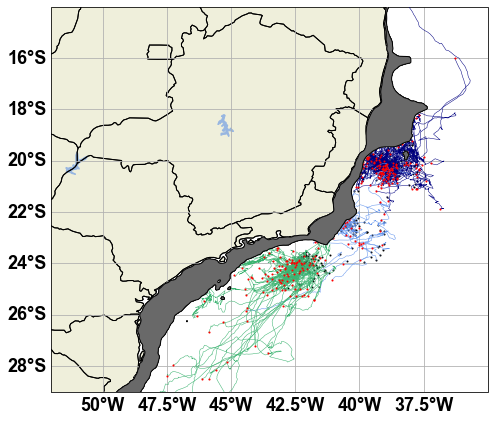

In [26]:

ltmn1=-28;ltmx1=-12;lnmn1=-46;lnmx1=-35.

# lnmn=-43;lnmx=-36;ltmn=-25;ltmx=-18;
fig1(sizeh=6.6,sizev=7.23,lnmn=lnmn1,lnmx=lnmx1,ltmn=ltmn1,ltmx=ltmx1)

for itt in range(len(edatabase)):
    ltmn,ltmx,lnmn,lnmx,nnc,pole,colorx,streddy=edatabase[itt]
    edatabase=[[-16,-14,-39.5,-37.5,anc,1,'lightsalmon','IE'],
                [-18,-16,-39,-37,anc,1,'chocolate','RCE'],
                [-20,-18,-38,-36,anc,1,'crimson','AE'],
                [-21.4,-19.25,-40.250,-37.750,cnc,-1,'navy','VE'],
                [-22.5,-20.5,-40.725,-38.725,anc,1,'darkorange','SVE'],
                [-24,-22,-41,-39,cnc,-1,'cornflowerblue','CSTE'],
                [-25,-23,-43,-41,cnc,-1,'mediumseagreen','CFE'],]

    if pole==-1:
        xtrack=nnc['track'][:]
        xobs=nnc['observation_number'][:]
        xlon,xlat=nnc['longitude'][:],nnc['latitude'][:]
        xlon=np.where(xlon>180,xlon-360,xlon)

        xtrack=np.int_(xtrack.data)

        'Condition 1 - Excluding NH++'
        condx=(xlon>ilnmn-10)&(xlon<ilnmx+10)&(xlat>iltmn-10)&(xlat<iltmx+10) #esse é o certo

        xtrack0=xtrack[condx]


        'Condition 1b - Filtering Area'
        xxx=(xobs[condx]==0)
        xx1=(xlon[condx][xxx]>lnmn)&(xlon[condx][xxx]<lnmx)&(xlat[condx][xxx]>ltmn)&(xlat[condx][xxx]<ltmx)
        ixs=xtrack0[xxx][xx1] #indices iniciais que precisam ser retirados com  o resto de suas tracks
        condx1=np.hstack([np.where(xtrack0==iy)[0] for iy in ixs])

        xtrack1=xtrack0[condx1]


        'Condition 2 - Bathtymetry'
        xxx=(xobs[condx][condx1]==0)
        xbol=[pseg.contains_point((xlon[condx][condx1][iy],xlat[condx][condx1][iy])) for iy in np.where(xxx)[0] ]
        icx=xtrack1[xxx][~np.array(xbol)]
        condx2=np.hstack([np.where(xtrack1==iy)[0] for iy in icx])

        xtrack2=xtrack1[condx2]



        'Condition 3 - Buffer zone'
        xxx=(xobs[condx][condx1][condx2]==0)
        xbol=[ddseg.contains_point((xlon[condx][condx1][condx2][iy],xlat[condx][condx1][condx2][iy])) for iy in np.where(xxx)[0] ]
        icx=xtrack2[xxx][np.array(xbol)]
        condx3=np.hstack([np.where(xtrack2==iy)[0] for iy in icx])

        xtrack3=xtrack2[condx3]


        ntrack=xtrack3.copy()
        del xtrack3,xtrack1,xtrack2


        
        uni=np.unique(ntrack)

        tobs=nnc['observation_number'][:]
        tlon=nnc['longitude'][:]
        tlat=nnc['latitude'][:]
        tlon=np.where(tlon>180,tlon-360,tlon)


        tlon=tlon[condx][condx1][condx2][condx3]
        tlat=tlat[condx][condx1][condx2][condx3]
        Tobs=tobs[condx][condx1][condx2][condx3]



        for ixs in uni:
            # xrr=np.mean(nnc['effective_radius'][:].data[ntrack==vic])/1e3
            # xpp=np.mean(nnc['amplitude'][:].data[ntrack==vic])*100

            # if (xrr>=40) & (xpp>=vamp):

            # ncc=len(tracked[vic]['centers'])
            # cp=tracked[vic]['polarity']
        
            plt.plot(tlon[ntrack==ixs][0],tlat[ntrack==ixs][0],color='k',marker='o',ms=1,zorder=20)
            plt.plot(tlon[ntrack==ixs],tlat[ntrack==ixs],color=colorx,linewidth=0.5,zorder=21)
            plt.plot(tlon[ntrack==ixs][-1],tlat[ntrack==ixs][-1],color='red',marker='X',ms=1,zorder=22)

            # plt.plot(*tracked[vic]['centers'][-1],color='k',marker='x',ms=3)

plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True,zorder=25)
plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=1,latlon=True,zorder=26)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Trajectories_cyclones.png')
# plt.close();

### AC

<ipython-input-10-20b1a6ddfd4d>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1508: UserWarning: The following kwargs were not used by contour: 'latlon'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1478: UserWarning: The following kwargs were not used by contour: 'latlon'
  result = matplotlib.axes.Axes.contour(self, *args, **kwargs)


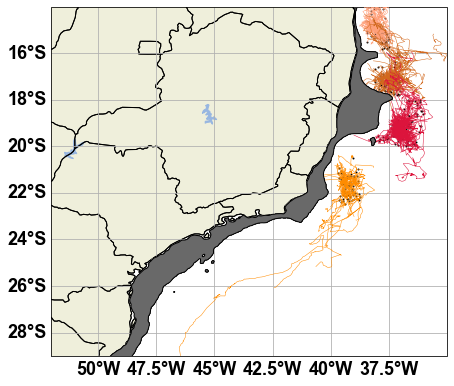

In [27]:
ltmn1=-28;ltmx1=-12;lnmn1=-46;lnmx1=-35.
# lnmn=-43;lnmx=-36;ltmn=-25;ltmx=-18;
fig1(sizeh=6.6,sizev=7.23,lnmn=lnmn1,lnmx=lnmx1,ltmn=ltmn1,ltmx=ltmx1)


for itt in range(len(edatabase)):
    ltmn,ltmx,lnmn,lnmx,nnc,pole,colorx,streddy=edatabase[itt]
    edatabase=[[-16,-14,-39.5,-37.5,anc,1,'lightsalmon','IE'],
                [-18,-16,-39,-37,anc,1,'chocolate','RCE'],
                [-20,-18,-38,-36,anc,1,'crimson','AE'],
                [-21.4,-19.25,-40.250,-37.750,cnc,-1,'navy','VE'],
                [-22.5,-20.5,-40.725,-38.725,anc,1,'darkorange','SVE'],
                [-24,-22,-41,-39,cnc,-1,'cornflowerblue','CSTE'],
                [-25,-23,-43,-41,cnc,-1,'mediumseagreen','CFE'],]


    xtrack=nnc['track'][:]
    xlon,xlat=nnc['longitude'][:]-360,nnc['latitude'][:]
    xtrack=np.int_(xtrack.data)



    if pole==1:
        xtrack=nnc['track'][:]
        xobs=nnc['observation_number'][:]
        xlon,xlat=nnc['longitude'][:],nnc['latitude'][:]
        xlon=np.where(xlon>180,xlon-360,xlon)

        xtrack=np.int_(xtrack.data)

        'Condition 1 - Excluding NH++'
        condx=(xlon>ilnmn-10)&(xlon<ilnmx+10)&(xlat>iltmn-10)&(xlat<iltmx+10) #esse é o certo

        xtrack0=xtrack[condx]


        'Condition 1b - Filtering Area'
        xxx=(xobs[condx]==0)
        xx1=(xlon[condx][xxx]>lnmn)&(xlon[condx][xxx]<lnmx)&(xlat[condx][xxx]>ltmn)&(xlat[condx][xxx]<ltmx)
        ixs=xtrack0[xxx][xx1] #indices iniciais que precisam ser retirados com  o resto de suas tracks
        condx1=np.hstack([np.where(xtrack0==iy)[0] for iy in ixs])

        xtrack1=xtrack0[condx1]


        'Condition 2 - Bathtymetry'
        xxx=(xobs[condx][condx1]==0)
        xbol=[pseg.contains_point((xlon[condx][condx1][iy],xlat[condx][condx1][iy])) for iy in np.where(xxx)[0] ]
        icx=xtrack1[xxx][~np.array(xbol)]
        condx2=np.hstack([np.where(xtrack1==iy)[0] for iy in icx])

        xtrack2=xtrack1[condx2]



        'Condition 3 - Buffer zone'
        xxx=(xobs[condx][condx1][condx2]==0)
        xbol=[ddseg.contains_point((xlon[condx][condx1][condx2][iy],xlat[condx][condx1][condx2][iy])) for iy in np.where(xxx)[0] ]
        icx=xtrack2[xxx][np.array(xbol)]
        condx3=np.hstack([np.where(xtrack2==iy)[0] for iy in icx])

        xtrack3=xtrack2[condx3]





        ntrack=xtrack3.copy()
        del xtrack3,xtrack1,xtrack2


        
        uni=np.unique(ntrack)

        tobs=nnc['observation_number'][:]
        tlon=nnc['longitude'][:]
        tlat=nnc['latitude'][:]
        tlon=np.where(tlon>180,tlon-360,tlon)


        tlon=tlon[condx][condx1][condx2][condx3]
        tlat=tlat[condx][condx1][condx2][condx3]
        Tobs=tobs[condx][condx1][condx2][condx3]



        for ixs in uni:
            # xrr=np.mean(nnc['effective_radius'][:].data[ntrack==vic])/1e3
            # xpp=np.mean(nnc['amplitude'][:].data[ntrack==vic])*100

            # if (xrr>=40) & (xpp>=vamp):

            # ncc=len(tracked[vic]['centers'])
            # cp=tracked[vic]['polarity']
        
            plt.plot(tlon[ntrack==ixs][0],tlat[ntrack==ixs][0],color='k',marker='o',ms=1,zorder=20)
            plt.plot(tlon[ntrack==ixs],tlat[ntrack==ixs],color=colorx,linewidth=0.5,zorder=21)
            # C.plot(tlon[ntrack==ixs][-1],tlat[ntrack==ixs][-1],color='red',marker='X',ms=1,zorder=22)

            # plt.plot(*tracked[vic]['centers'][-1],color='k',marker='x',ms=3)


plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True,zorder=25)
plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=1,latlon=True,zorder=26)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Trajectories_anticyclones.png')
# plt.close();
